# Walmart Sales Forecasting — XGBoost

**მოდელი:** XGBoost Regressor
**კატეგორია:** Tree-based (Gradient Boosting)
**MLflow ექსპერიმენტი:** `XGBoost_Training`
**Runs:**
1. `XGBoost_EDA` — exploratory data analysis
2. `XGBoost_Cleaning` — preprocessing pipeline validation
3. `XGBoost_Feature_Selection` — feature set comparison
4. `XGBoost_CrossValidation` — TimeSeriesSplit CV
5. `XGBoost_HyperparameterTuning` — curated configuration comparison
6. `XGBoost_Final` — საუკეთესო Pipeline (raw → prediction)

**მეტრიკა:** WMAE (Weighted Mean Absolute Error) — competition-ის ოფიციალური. სადღესასწაულო კვირებს ×5 წონა.

## 1. Setup

In [1]:
# ინსტალაცია
!pip install xgboost mlflow dagshub --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 126.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models.signature import infer_signature

print(f"XGBoost version: {xgb.__version__}")
print(f"MLflow version: {mlflow.__version__}")

XGBoost version: 3.3.0
MLflow version: 3.14.0


In [3]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Data directory: /content/drive/MyDrive/walmart/data


In [4]:
# DagsHub + MLflow setup
import dagshub

DAGSHUB_USERNAME = "zberi23"
DAGSHUB_REPO = "walmart-forecasting"

dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO, mlflow=True)

EXPERIMENT_NAME = "XGBoost_Training"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=f35db3a5-1c09-4f99-8481-2de4698fe546&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=7d88ad60008db97ab09880ee536fd6ae50d2e8337a1210916c7edc00cdb6cd73




Accessing as gbera23-dev

Initialized MLflow to track repo "zberi23/walmart-forecasting"

Repository zberi23/walmart-forecasting initialized!

MLflow tracking URI: https://dagshub.com/zberi23/walmart-forecasting.mlflow
Experiment: XGBoost_Training


## 2. Raw Data Loading

Pipeline იმუშავებს raw test set-ზე. ამიტომ სამივე original ფაილს ვტვირთავთ, არა preprocessed CSV-ს.

In [5]:
# Raw მონაცემები — Pipeline-ის მოთხოვნის დასაცავად
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')
stores_raw = pd.read_csv(f'{DATA_DIR}/stores.csv')
features_raw = pd.read_csv(f'{DATA_DIR}/features.csv.zip')

for df in [train_raw, test_raw, features_raw]:
    df['Date'] = pd.to_datetime(df['Date'])

print(f"Train raw: {train_raw.shape}")
print(f"Test raw:  {test_raw.shape}")
print(f"Stores:    {stores_raw.shape}")
print(f"Features:  {features_raw.shape}")

train_raw.head(3)

Train raw: (421570, 5)
Test raw:  (115064, 4)
Stores:    (45, 3)
Features:  (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


## 3. Exploratory Data Analysis

ვაანალიზებთ სამ ფაილს ცალ-ცალკე და ერთად, სანამ preprocessing pipeline-ს ავაშენებთ. მიზანია გავიგოთ განაწილებები, missing values-ის სტრუქტურა, სეზონურობა და holiday ეფექტი — რაც პირდაპირ განსაზღვრავს ქვემოთ არსებულ feature engineering-ის არჩევანს.

In [6]:
eda = train_raw.merge(stores_raw, on='Store', how='left') \
                .merge(features_raw, on=['Store', 'Date', 'IsHoliday'], how='left')

print("Merged EDA frame:", eda.shape)
eda.describe(include='all').T.head(20)

Merged EDA frame: (421570, 16)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,421570.0,NaN,NaN,NaN,22.200546,1.0,11.0,22.0,33.0,45.0,12.785297
Dept,421570.0,NaN,NaN,NaN,44.260317,1.0,18.0,37.0,74.0,99.0,30.492054
Date,421570,NaN,NaN,NaN,2011-06-18 08:30:31.963375104,2010-02-05 00:00:00,2010-10-08 00:00:00,2011-06-17 00:00:00,2012-02-24 00:00:00,2012-10-26 00:00:00,NaN
Weekly_Sales,421570.0,NaN,NaN,NaN,15981.258123,-4988.94,2079.65,7612.03,20205.8525,693099.36,22711.183519
IsHoliday,421570,2,False,391909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,421570,3,A,215478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,421570.0,NaN,NaN,NaN,136727.915739,34875.0,93638.0,140167.0,202505.0,219622.0,60980.583328
Temperature,421570.0,NaN,NaN,NaN,60.090059,-2.06,46.68,62.09,74.28,100.14,18.447931
Fuel_Price,421570.0,NaN,NaN,NaN,3.361027,2.472,2.933,3.452,3.738,4.468,0.458515
MarkDown1,150681.0,NaN,NaN,NaN,7246.420196,0.27,2240.27,5347.45,9210.9,88646.76,8291.221345


### 3.1 Missing values

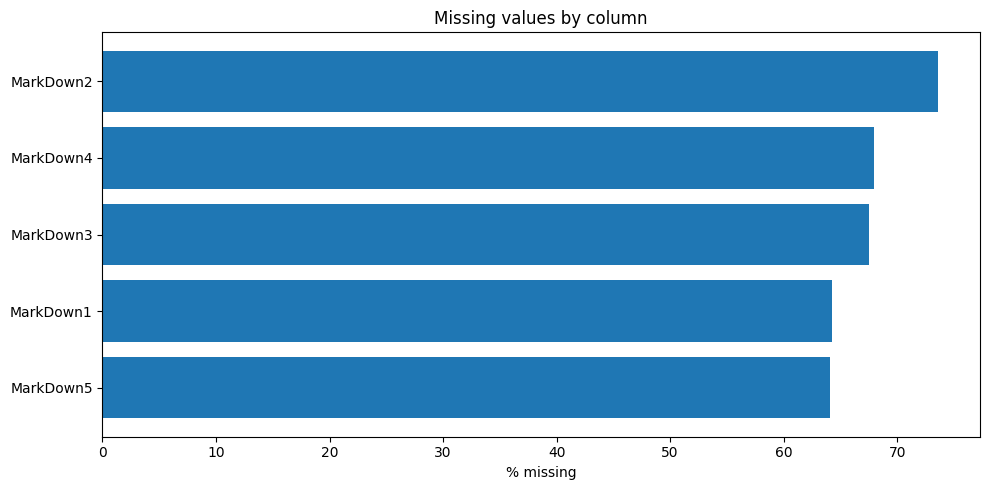

MarkDown2    73.611025
MarkDown4    67.984676
MarkDown3    67.480845
MarkDown1    64.257181
MarkDown5    64.079038
dtype: float64


In [7]:
missing = eda.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
plt.barh(missing.index[::-1], missing.values[::-1])
plt.xlabel('% missing')
plt.title('Missing values by column')
plt.tight_layout()
plt.show()

print(missing)

MarkDown1–5 არის ყველაზე missing-heavy სვეტები (ეს პროდაქცია დაიწყო მხოლოდ 2011 ნოემბრიდან), CPI/Unemployment-ს რამდენიმე ხარვეზი აქვს store-level დროის ღერძზე.

### 3.2 Target distribution

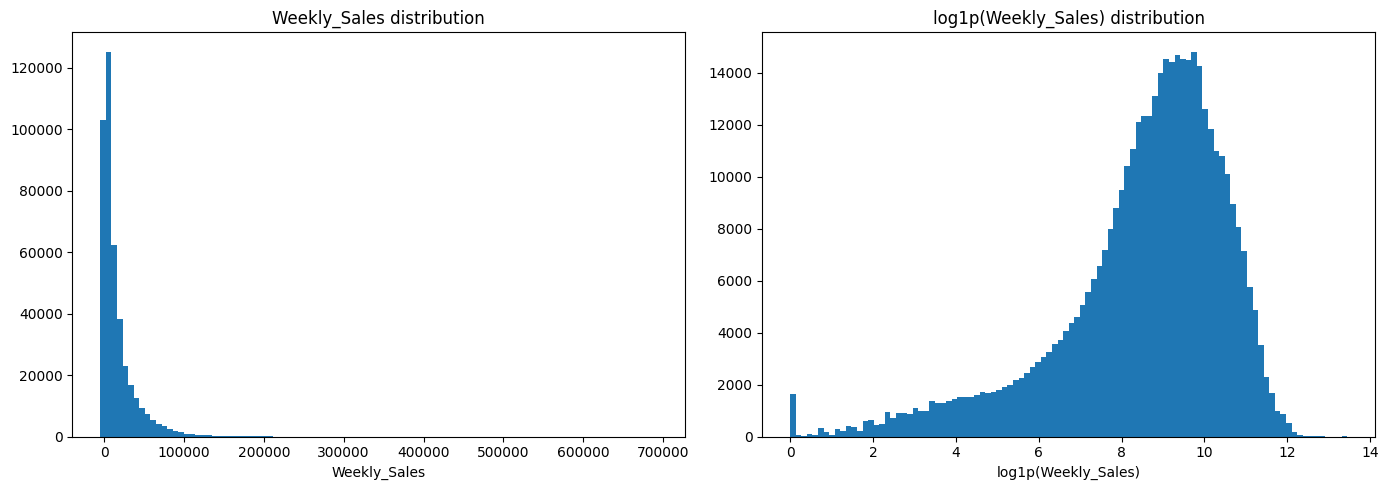

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64
Negative Weekly_Sales rows: 1285


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(eda['Weekly_Sales'], bins=100)
axes[0].set_title('Weekly_Sales distribution')
axes[0].set_xlabel('Weekly_Sales')

axes[1].hist(np.log1p(eda['Weekly_Sales'].clip(lower=0)), bins=100)
axes[1].set_title('log1p(Weekly_Sales) distribution')
axes[1].set_xlabel('log1p(Weekly_Sales)')
plt.tight_layout()
plt.show()

print(eda['Weekly_Sales'].describe())
print(f"Negative Weekly_Sales rows: {(eda['Weekly_Sales'] < 0).sum()}")

### 3.3 Seasonality and holiday effect

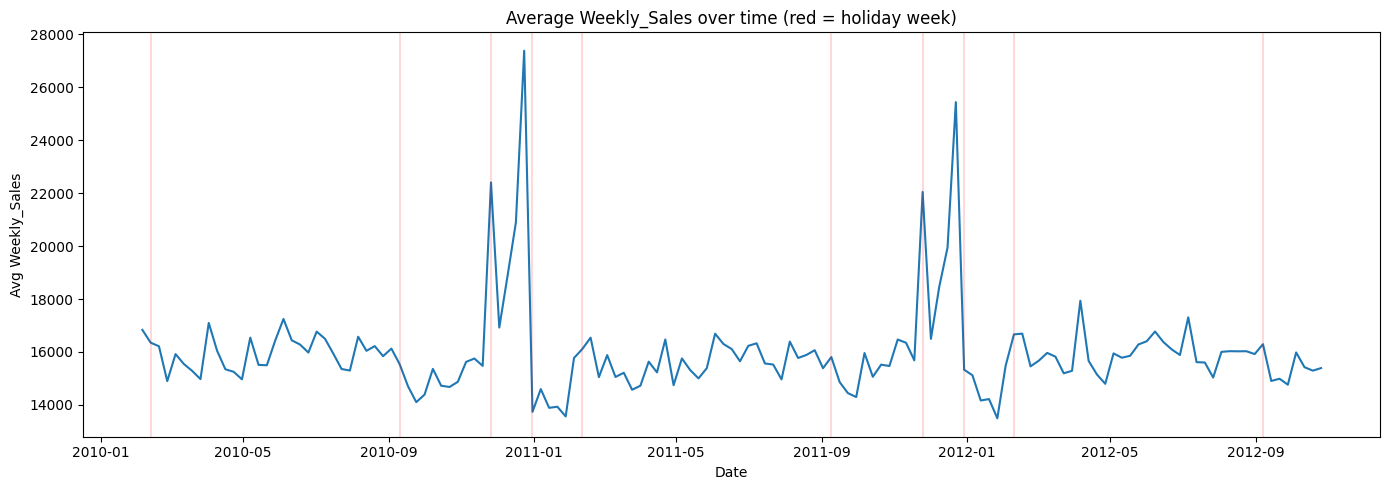

                   mean   median   count
IsHoliday                               
False      15901.445069  7589.95  391909
True       17035.823187  7947.74   29661


In [9]:
weekly_avg = eda.groupby('Date')['Weekly_Sales'].mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_avg.index, weekly_avg.values)
holiday_dates = eda.loc[eda['IsHoliday'], 'Date'].unique()
for d in holiday_dates:
    plt.axvline(pd.Timestamp(d), color='red', alpha=0.15)
plt.title('Average Weekly_Sales over time (red = holiday week)')
plt.xlabel('Date')
plt.ylabel('Avg Weekly_Sales')
plt.tight_layout()
plt.show()

print(eda.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'median', 'count']))

### 3.4 Store type / size / department effects

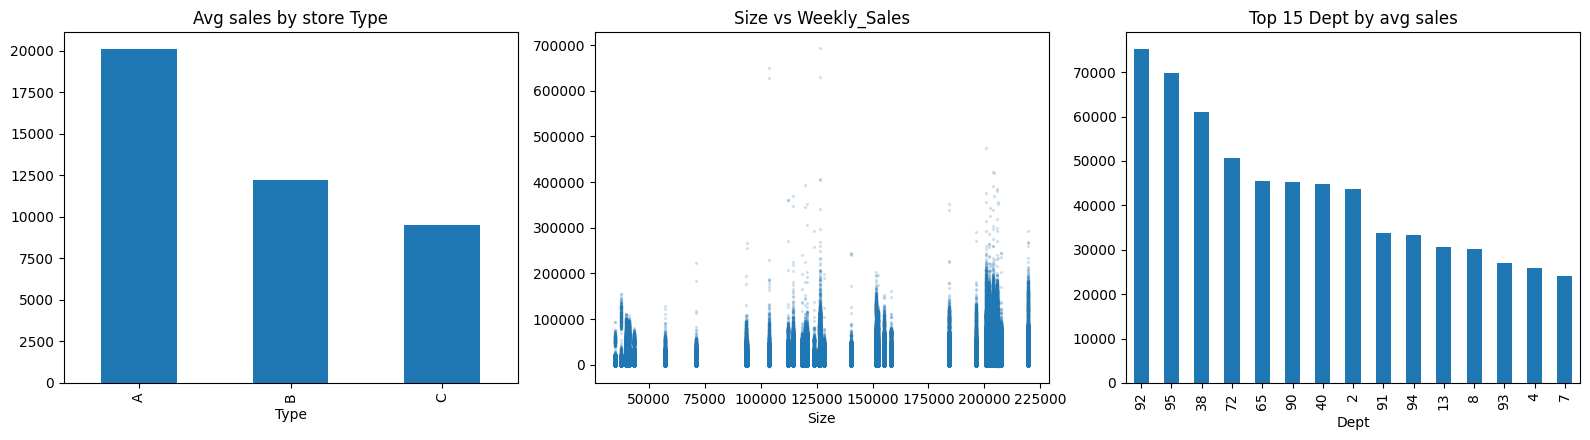

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

eda.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar', ax=axes[0], title='Avg sales by store Type')
axes[1].scatter(eda['Size'], eda['Weekly_Sales'], s=2, alpha=0.15)
axes[1].set_title('Size vs Weekly_Sales')
axes[1].set_xlabel('Size')

top_depts = eda.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(15)
top_depts.plot(kind='bar', ax=axes[2], title='Top 15 Dept by avg sales')

plt.tight_layout()
plt.show()

### 3.5 Correlation between numeric covariates

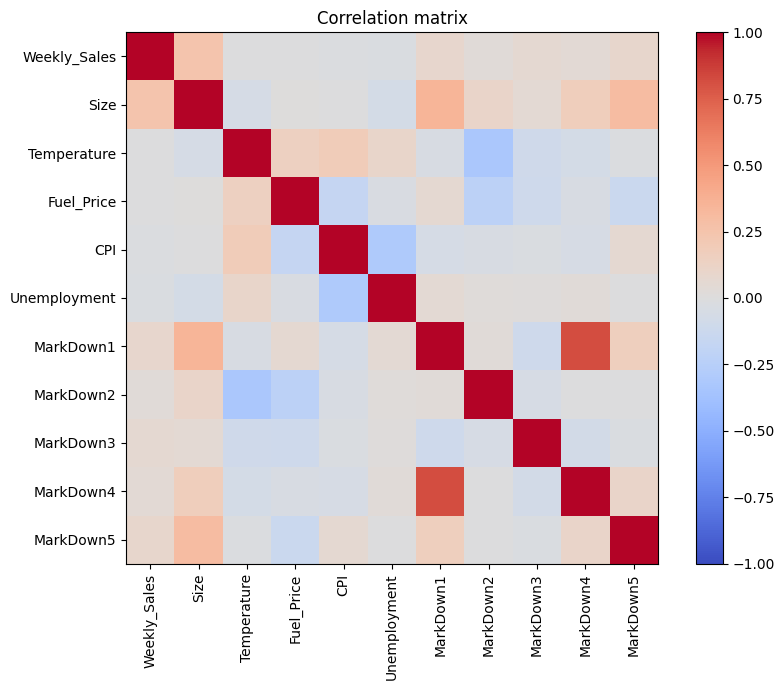

,Weekly_Sales
Weekly_Sales,1.000000
Size,0.243828
MarkDown5,0.090362
MarkDown1,0.085251
MarkDown3,0.060385
MarkDown4,0.045414
MarkDown2,0.024130
Fuel_Price,-0.000120
Temperature,-0.002312
CPI,-0.020921


In [11]:
num_cols = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
            'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
corr = eda[num_cols].corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

corr['Weekly_Sales'].sort_values(ascending=False)

**დასკვნები EDA-დან:**
- Weekly_Sales ძლიერად skewed არის, Store/Dept/Size ცვლადები ყველაზე მეტ ვარიაციას ხსნიან.
- Holiday კვირები საშუალოდ უფრო მაღალი გაყიდვებით გამოირჩევა — ეს ამართლებს competition-ის ×5 წონას.
- ეკონომიკური ცვლადები (CPI, Fuel_Price, Unemployment, Temperature) სუსტად კორელირებენ სამიზნესთან პირდაპირ, მაგრამ store/dept-ის კონტექსტში მაინც სასარგებლო სიგნალს იძლევიან.
- Dept დონეზე დიდი განსხვავებაა საშუალო გაყიდვებში — ეს განაპირობებს Dept-დონის სტატისტიკური ფიჩერების დამატებას ქვემოთ.

## 4. Custom Preprocessor

sklearn-compatible Transformer, რომელიც Pipeline-ის შიგნით raw test set-ს (`Store, Dept, Date, IsHoliday`) გარდაქმნის მოდელისთვის მზა ფიჩერების მატრიცად. თარიღზე/store-ზე დაფუძნებულ ფიჩერებთან ერთად, Preprocessor-ი `fit`-ის დროს, მხოლოდ `train`-ის ისტორიიდან, აგებს ორი ტიპის სტატისტიკურ ფიჩერს:

- **Store×Dept lag/rolling ისტორია** — რამდენი გაყიდა კონკრეტულმა store-department-მა წინა კვირებში
- **Dept×Week სეზონური საშუალო** — რამდენს ყიდის ეს დეპარტამენტი, საშუალოდ, წლის ამ კონკრეტულ კვირაში ყველა store-ში ერთად (ეს პირდაპირ იჭერს holiday-სპეციფიკურ spike-ებს — Thanksgiving/Christmas კვირებში გარკვეული დეპარტამენტები 3-4x მეტს ყიდიან, და ეს сპეციფიკურად ×5 წონიანი კვირებია)

`transform` არასდროს არ საჭიროებს სამიზნე სვეტს (`Weekly_Sales`) — ის მხოლოდ `fit`-ის დროს დაზოგილ სტატისტიკებს იყენებს, ისე რომ raw `test.csv`-ზეც უცვლელად იმუშაოს.

In [12]:
class WalmartPreprocessor(BaseEstimator, TransformerMixin):
    """
    Custom Pipeline transformer, რომელიც raw Walmart CSV-ებს გარდაქმნის
    მოდელისთვის მზა ფიჩერების მატრიცად — calendar/store ფიჩერების გარდა
    Store×Dept lag/rolling ისტორიას და Dept×Week სეზონურ საშუალოებსაც
    fit-ის დროს აგებს, მხოლოდ train-ის ისტორიაზე დაყრდნობით.
    """

    def __init__(self, stores_df, features_df):
        self.stores_df = stores_df.copy()
        self.features_df = features_df.copy()

        if not pd.api.types.is_datetime64_any_dtype(self.features_df['Date']):
            self.features_df['Date'] = pd.to_datetime(self.features_df['Date'])

        self._dept_rank_map = None

    def fit(self, X, y=None):
        dept_counts = X['Dept'].value_counts()
        self._dept_rank_map = {d: r for r, d in enumerate(dept_counts.index)}

        if y is None and 'Weekly_Sales' in X.columns:
            y = X['Weekly_Sales'].values

        hist = X[['Store', 'Dept', 'Date']].copy()
        if not pd.api.types.is_datetime64_any_dtype(hist['Date']):
            hist['Date'] = pd.to_datetime(hist['Date'])
        hist['Weekly_Sales'] = np.asarray(y, dtype=float)
        hist = hist.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

        grp = hist.groupby(['Store', 'Dept'])['Weekly_Sales']

        hist['lag_1'] = grp.shift(1)
        hist['lag_52'] = grp.shift(52)
        hist['roll_4_mean'] = grp.transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
        hist['roll_12_mean'] = grp.transform(lambda s: s.shift(1).rolling(12, min_periods=1).mean())
        hist['store_dept_expanding_median'] = grp.transform(lambda s: s.shift(1).expanding(min_periods=1).median())

        lag_feature_cols = ['lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean', 'store_dept_expanding_median']

        global_median = hist['Weekly_Sales'].median()
        self._global_fallback = {col: global_median for col in lag_feature_cols}
        self._lag_feature_cols = lag_feature_cols

        self._history_features = hist[['Store', 'Dept', 'Date'] + lag_feature_cols] \
            .sort_values('Date').reset_index(drop=True)

        # Dept×Week სეზონური საშუალო — mixureagat train-ის მთელ ისტორიაზე,
        # ისე რომ ერთხელ გამოთვლილი აგრეგატი ერთნაირად ერგოს val/test-საც (leakage-free,
        # რადგან მხოლოდ fit-ის train slice-იდანაა ნაანგარიშები)
        dw = hist.copy()
        dw['Week'] = dw['Date'].dt.isocalendar().week.astype(int)
        self._dept_week_table = dw.groupby(['Dept', 'Week'])['Weekly_Sales'].mean()
        self._dept_week_global_mean = dw['Weekly_Sales'].mean()

        return self

    def transform(self, X):
        df = X.copy()

        if not pd.api.types.is_datetime64_any_dtype(df['Date']):
            df['Date'] = pd.to_datetime(df['Date'])

        # ---- Merge ----
        df = df.merge(self.features_df, on=['Store', 'Date', 'IsHoliday'], how='left')
        df = df.merge(self.stores_df, on='Store', how='left')

        # ---- Missing values ----
        for col in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']:
            df[col] = df[col].fillna(0)

        for col in ['CPI', 'Unemployment', 'Temperature', 'Fuel_Price']:
            df[col] = df.groupby('Store')[col].transform(
                lambda x: x.fillna(method='ffill').fillna(method='bfill')
            )

        # ---- Calendar features ----
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
        df['Day_of_Year'] = df['Date'].dt.dayofyear
        df['Quarter'] = df['Date'].dt.quarter
        df['WeekOfMonth'] = ((df['Date'].dt.day - 1) // 7 + 1).astype(int)

        # ---- Holiday-specific flags ----
        super_bowl = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        labor_day = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        thanksgiving = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        christmas = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])
        all_holidays = super_bowl.append(labor_day).append(thanksgiving).append(christmas)

        df['Is_SuperBowl'] = df['Date'].isin(super_bowl).astype(int)
        df['Is_LaborDay'] = df['Date'].isin(labor_day).astype(int)
        df['Is_Thanksgiving'] = df['Date'].isin(thanksgiving).astype(int)
        df['Is_Christmas'] = df['Date'].isin(christmas).astype(int)

        holiday_sorted = pd.Series(sorted(all_holidays))
        def days_to_nearest(d):
            diffs = (holiday_sorted - d).dt.days
            return diffs.abs().min()
        df['Days_To_Holiday'] = df['Date'].apply(days_to_nearest)

        # ---- Cyclical encoding ----
        df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
        df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
        df['Week_Sin'] = np.sin(2 * np.pi * df['Week'] / 52)
        df['Week_Cos'] = np.cos(2 * np.pi * df['Week'] / 52)

        # ---- Store / markdown derived features ----
        markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
        df['MarkDown_Total'] = df[markdown_cols].sum(axis=1)
        df['MarkDown_Active_Count'] = (df[markdown_cols] > 0).sum(axis=1)
        df['Size_Per_Dept_Rank'] = df['Dept'].map(self._dept_rank_map).fillna(-1)

        size_bins = [0, 50000, 100000, 150000, 200000, np.inf]
        df['Size_Bucket'] = pd.cut(df['Size'], bins=size_bins, labels=False)

        # ---- Categorical encoding ----
        type_mapping = {'A': 0, 'B': 1, 'C': 2}
        df['Type_Encoded'] = df['Type'].map(type_mapping)
        df['IsHoliday'] = df['IsHoliday'].astype(int)

        # ---- Dept×Week სეზონური საშუალო ----
        dw_index = pd.MultiIndex.from_arrays([df['Dept'], df['Week']])
        df['Dept_Week_Seasonal_Avg'] = dw_index.map(self._dept_week_table).to_numpy()
        df['Dept_Week_Seasonal_Avg'] = pd.Series(df['Dept_Week_Seasonal_Avg']).fillna(self._dept_week_global_mean).values

        # ---- Store×Dept lag / rolling ისტორია (merge_asof, leakage-safe) ----
        left = df[['Store', 'Dept', 'Date']].sort_values('Date')
        merged_lags = pd.merge_asof(
            left,
            self._history_features,
            on='Date',
            by=['Store', 'Dept'],
            direction='backward'
        ).set_index(left.index).sort_index()
        for col in self._lag_feature_cols:
            df[col] = merged_lags[col].fillna(self._global_fallback[col])

        df = df.drop(columns=['Date', 'Type'])
        return df


# ტესტი: Preprocessor მუშაობს raw მონაცემებზე?
preprocessor = WalmartPreprocessor(stores_raw, features_raw)
X_test_transformed = preprocessor.fit(train_raw).transform(test_raw)
print(f"Test raw shape: {test_raw.shape}")
print(f"Test transformed: {X_test_transformed.shape}")
print(f"Columns: {list(X_test_transformed.columns)}")

Test raw shape: (115064, 4)
Test transformed: (115064, 39)
Columns: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Day_of_Year', 'Quarter', 'WeekOfMonth', 'Is_MonthStart', 'Is_MonthEnd', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'Days_To_Holiday', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos', 'MarkDown_Total', 'MarkDown_Active_Count', 'Size_Per_Dept_Rank', 'Size_Bucket', 'Type_Encoded', 'lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean']


## 5. WMAE Metric + მონაცემების მომზადება

Train/val split დროზეა დაფუძნებული (ბოლო 10%), რომ ვალიდაცია საკმარისად დიდი და სტაბილური იყოს. Holiday-წონები (`w_train`, `w_val`) წინასწარვე ვითვლით raw `IsHoliday`-დან და ვიყენებთ როგორც ტრენინგში (`sample_weight`), ისე შეფასებაში — მოდელს პირდაპირ ვაიძულებთ დღესასწაულების კვირებზე მეტი ყურადღება მიაქციოს, რასაც competition-ის ოფიციალური მეტრიკა ისედაც ითხოვს.

In [13]:
def wmae(y_true, y_pred, weights):
    """
    Weighted Mean Absolute Error — competition metric.
    სადღესასწაულო კვირებს წონა 5, სხვას 1.
    """
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


def get_weights(is_holiday):
    """Holiday კვირას 5, სხვა 1."""
    return np.where(is_holiday == 1, 5, 1)


# Train/validation split — TIME-BASED (არა random!)
train_sorted = train_raw.sort_values('Date').reset_index(drop=True)
split_date = train_sorted['Date'].quantile(0.9)

X_train_raw = train_sorted[train_sorted['Date'] < split_date].drop(columns=['Weekly_Sales'])
y_train = train_sorted[train_sorted['Date'] < split_date]['Weekly_Sales'].values

X_val_raw = train_sorted[train_sorted['Date'] >= split_date].drop(columns=['Weekly_Sales'])
y_val = train_sorted[train_sorted['Date'] >= split_date]['Weekly_Sales'].values

# Holiday sample weights — ტრენინგისთვისაც და შეფასებისთვისაც
w_train = get_weights(X_train_raw['IsHoliday'].values.astype(int))
w_val = get_weights(X_val_raw['IsHoliday'].values.astype(int))

print(f"Train: {X_train_raw.shape}, val: {X_val_raw.shape}")
print(f"Train date range: {X_train_raw['Date'].min()} → {X_train_raw['Date'].max()}")
print(f"Val date range:   {X_val_raw['Date'].min()} → {X_val_raw['Date'].max()}")

Train: (377155, 4), val: (44415, 4)
Train date range: 2010-02-05 00:00:00 → 2012-07-13 00:00:00
Val date range:   2012-07-20 00:00:00 → 2012-10-26 00:00:00


## 6. Run 1 — `XGBoost_Cleaning`

Preprocessing pipeline validation. `WalmartPreprocessor` fit-ავს Dept-frequency მეპინგს მხოლოდ train ნაწილზე და ცალ-ცალკე გარდაქმნის train/val/test-ს, რომ raw test-ზეც იმუშაოს უცვლელად.

In [14]:
with mlflow.start_run(run_name="XGBoost_Cleaning"):
    preprocessor = WalmartPreprocessor(stores_raw, features_raw)
    preprocessor.fit(X_train_raw, y_train)

    X_train_processed = preprocessor.transform(X_train_raw)
    X_val_processed = preprocessor.transform(X_val_raw)
    X_test_processed = preprocessor.transform(test_raw)

    train_nans = X_train_processed.isnull().sum().sum()
    val_nans = X_val_processed.isnull().sum().sum()
    test_nans = X_test_processed.isnull().sum().sum()

    mlflow.log_param("train_rows_raw", X_train_raw.shape[0])
    mlflow.log_param("train_rows_processed", X_train_processed.shape[0])
    mlflow.log_param("test_rows_raw", test_raw.shape[0])
    mlflow.log_param("test_rows_processed", X_test_processed.shape[0])
    mlflow.log_param("n_features_after_preprocessing", X_train_processed.shape[1])
    mlflow.log_param("markdown_fill_value", 0)
    mlflow.log_param("cpi_unemployment_temp_fuel_fill_method", "groupby_store_ffill_bfill")
    mlflow.log_param("features", list(X_train_processed.columns))

    mlflow.log_metric("train_missing_after_clean", train_nans)
    mlflow.log_metric("val_missing_after_clean", val_nans)
    mlflow.log_metric("test_missing_after_clean", test_nans)

    mlflow.set_tag("stage", "cleaning")

    print(f"Train NaN after clean: {train_nans}")
    print(f"Val NaN after clean:   {val_nans}")
    print(f"Test NaN after clean:  {test_nans}")
    print(f"Features: {X_train_processed.shape[1]}")

Train NaN after clean: 0
Val NaN after clean:   0
Test NaN after clean:  0
Features: 39
🏃 View run XGBoost_Cleaning at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/08c2e5d380804a78afe8eb6adb105642
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 7. Run 2 — `XGBoost_Feature_Selection`

სხვადასხვა feature set-ის შედარება baseline XGBoost-ით, holiday sample weight-ით (`sample_weight=w_train`):

- **all** — ყველა ფიჩერი
- **no_markdown** — MarkDown-ების გარეშე
- **core** — მხოლოდ ძირითადი date + store ფიჩერები
- **extended** — core + Store×Dept lag/rolling ისტორია (`lag_1`, `lag_52`, `roll_4_mean`, `roll_12_mean`, `store_dept_expanding_median`) და Dept×Week სეზონური საშუალო (`Dept_Week_Seasonal_Avg`)

In [15]:
FEATURE_SETS = {
    "all": list(X_train_processed.columns),

    "no_markdown": [c for c in X_train_processed.columns
                    if c not in ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']],

    "core": ['Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
             'Year', 'Month', 'Week', 'Day_of_Year',
             'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
             'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos'],

    "extended": ['Store', 'Dept', 'IsHoliday', 'Size', 'Type_Encoded',
                 'Year', 'Month', 'Week', 'Day_of_Year', 'Quarter',
                 'WeekOfMonth', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas',
                 'Days_To_Holiday', 'Month_Sin', 'Month_Cos', 'Week_Sin', 'Week_Cos',
                 'MarkDown_Total', 'MarkDown_Active_Count', 'Size_Bucket', 'Size_Per_Dept_Rank',
                 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
                 'lag_1', 'lag_52', 'roll_4_mean', 'roll_12_mean',
                 'store_dept_expanding_median', 'Dept_Week_Seasonal_Avg'],
}

BASELINE_PARAMS = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.1,
    'random_state': 42,
    'tree_method': 'hist',
    'n_jobs': -1,
}

feature_selection_results = {}

with mlflow.start_run(run_name="XGBoost_Feature_Selection"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("feature_sets_tested", list(FEATURE_SETS.keys()))
    mlflow.log_param("sample_weighted_training", True)

    for fs_name, feats in FEATURE_SETS.items():
        with mlflow.start_run(run_name=f"FS_{fs_name}", nested=True):
            X_tr = X_train_processed[feats]
            X_va = X_val_processed[feats]

            model = xgb.XGBRegressor(**BASELINE_PARAMS)
            model.fit(X_tr, y_train, sample_weight=w_train, verbose=False)

            preds = model.predict(X_va)
            score = wmae(y_val, preds, w_val)

            feature_selection_results[fs_name] = score

            mlflow.log_param("feature_set", fs_name)
            mlflow.log_param("n_features", len(feats))
            mlflow.log_metric("val_wmae", score)

            print(f"[{fs_name:12}] n_features={len(feats):3d}, WMAE = {score:.2f}")

    best_fs = min(feature_selection_results, key=feature_selection_results.get)
    mlflow.log_metric("best_val_wmae", feature_selection_results[best_fs])
    mlflow.log_param("best_feature_set", best_fs)
    mlflow.set_tag("stage", "feature_selection")

    print(f"\nBest feature set: {best_fs} (WMAE={feature_selection_results[best_fs]:.2f})")

BEST_FEATURES = FEATURE_SETS[best_fs]

[all         ] n_features= 39, WMAE = 2471.54
🏃 View run FS_all at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/19edc50ce1424b1abd9a0830d05876e1
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[no_markdown ] n_features= 34, WMAE = 2450.70
🏃 View run FS_no_markdown at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/33aa716296934bce99f42db10d78cc63
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[core        ] n_features= 17, WMAE = 2265.36
🏃 View run FS_core at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/f485a316fbcb4333b39914d9944972a7
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[extended    ] n_features= 34, WMAE = 2447.98
🏃 View run FS_extended at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/d45a740a91514f8195ea99dfcaaed16d

## 8. Run 3 — `XGBoost_CrossValidation`

**TimeSeriesSplit** — time-series-ისთვის სპეციფიკური CV. K-Fold-ს არ ვიყენებთ, რადგან შემთხვევითი shuffle დროის თანმიმდევრობას არღვევს.

TimeSeriesSplit ინახავს დროის თანმიმდევრობას: fold-1 = train[0:20%], val[20:40%]; fold-2 = train[0:40%], val[40:60%]; ა.შ.

თითოეულ fold-ში `WalmartPreprocessor` თავიდან fit-დება მხოლოდ იმ fold-ის training slice-ზე, რომ lag/rolling/სეზონური ფიჩერები არასდროს ხედავდნენ მომავალ fold-ებს. მოდელი holiday sample weight-ით ტრენინგდება, საბოლოო Pipeline-ის იდენტური რეჟიმით.

In [16]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
cv_scores = []

with mlflow.start_run(run_name="XGBoost_CrossValidation"):
    mlflow.log_params(BASELINE_PARAMS)
    mlflow.log_param("cv_method", "TimeSeriesSplit")
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("feature_set", best_fs)
    mlflow.log_param("sample_weighted_training", True)

    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train_raw)):
        X_tr_raw_fold = X_train_raw.iloc[tr_idx]
        y_tr_fold = y_train[tr_idx]
        X_va_raw_fold = X_train_raw.iloc[va_idx]
        y_va_fold = y_train[va_idx]

        w_tr_fold = get_weights(X_tr_raw_fold['IsHoliday'].values.astype(int))
        w_va_fold = get_weights(X_va_raw_fold['IsHoliday'].values.astype(int))

        fold_preprocessor = WalmartPreprocessor(stores_raw, features_raw)
        fold_preprocessor.fit(X_tr_raw_fold, y_tr_fold)

        X_tr_fold = fold_preprocessor.transform(X_tr_raw_fold)[BEST_FEATURES]
        X_va_fold = fold_preprocessor.transform(X_va_raw_fold)[BEST_FEATURES]

        model = xgb.XGBRegressor(**BASELINE_PARAMS)
        model.fit(X_tr_fold, y_tr_fold, sample_weight=w_tr_fold, verbose=False)

        preds = model.predict(X_va_fold)
        score = wmae(y_va_fold, preds, w_va_fold)

        cv_scores.append(score)
        mlflow.log_metric("fold_wmae", score, step=fold)
        print(f"Fold {fold+1}: WMAE = {score:.2f}")

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)

    mlflow.log_metric("cv_wmae_mean", mean_score)
    mlflow.log_metric("cv_wmae_std", std_score)
    mlflow.set_tag("stage", "cross_validation")

    print(f"\nCV WMAE: {mean_score:.2f} ± {std_score:.2f}")

Fold 1: WMAE = 4342.00
Fold 2: WMAE = 4532.68
Fold 3: WMAE = 2517.24
Fold 4: WMAE = 2797.96
Fold 5: WMAE = 2574.70

CV WMAE: 3352.92 ± 892.42
🏃 View run XGBoost_CrossValidation at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/63611dffb5ea498ebd1e66b384c96290
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 9. Run 4 — `XGBoost_HyperparameterTuning`

ცხრა curated კონფიგურაციის შედარება — თითოეული სხვადასხვა depth/learning_rate/regularization balance-ს წარმოადგენს, dense tabular gradient boosting-ისთვის ჩვეულებრივ კარგად მომუშავე დიაპაზონებში. შეფასება ხდება დროით მოწესრიგებულ hold-out ვალიდაციაზე (`X_val_processed`), holiday sample weight-ით.

In [17]:
CANDIDATE_CONFIGS = [
    {"max_depth": 6,  "learning_rate": 0.08, "n_estimators": 400, "subsample": 0.8,  "colsample_bytree": 0.8,  "min_child_weight": 3, "reg_alpha": 0.1,  "reg_lambda": 1.0, "gamma": 0.0},
    {"max_depth": 8,  "learning_rate": 0.05, "n_estimators": 600, "subsample": 0.8,  "colsample_bytree": 0.8,  "min_child_weight": 3, "reg_alpha": 0.1,  "reg_lambda": 1.0, "gamma": 0.0},
    {"max_depth": 8,  "learning_rate": 0.05, "n_estimators": 800, "subsample": 0.85, "colsample_bytree": 0.7,  "min_child_weight": 4, "reg_alpha": 0.05, "reg_lambda": 1.2, "gamma": 0.0},
    {"max_depth": 10, "learning_rate": 0.05, "n_estimators": 800, "subsample": 0.85, "colsample_bytree": 0.8,  "min_child_weight": 4, "reg_alpha": 0.05, "reg_lambda": 1.2, "gamma": 0.0},
    {"max_depth": 10, "learning_rate": 0.03, "n_estimators": 1000, "subsample": 0.85, "colsample_bytree": 0.8, "min_child_weight": 4, "reg_alpha": 0.05, "reg_lambda": 1.2, "gamma": 0.0},
    {"max_depth": 10, "learning_rate": 0.03, "n_estimators": 1200, "subsample": 0.9,  "colsample_bytree": 0.75, "min_child_weight": 5, "reg_alpha": 0.05, "reg_lambda": 1.5, "gamma": 0.05},
    {"max_depth": 12, "learning_rate": 0.03, "n_estimators": 1000, "subsample": 0.85, "colsample_bytree": 0.75, "min_child_weight": 5, "reg_alpha": 0.1,  "reg_lambda": 1.5, "gamma": 0.05},
    {"max_depth": 12, "learning_rate": 0.02, "n_estimators": 1500, "subsample": 0.9,  "colsample_bytree": 0.7,  "min_child_weight": 6, "reg_alpha": 0.1,  "reg_lambda": 1.5, "gamma": 0.05},
    {"max_depth": 14, "learning_rate": 0.02, "n_estimators": 1500, "subsample": 0.9,  "colsample_bytree": 0.7,  "min_child_weight": 6, "reg_alpha": 0.15, "reg_lambda": 2.0, "gamma": 0.1},
]

FIXED_PARAMS = {
    "random_state": 42,
    "tree_method": "hist",
    "n_jobs": -1,
}

print(f"Total configurations: {len(CANDIDATE_CONFIGS)}")

tuning_results = []

X_tr_tune = X_train_processed[BEST_FEATURES]
X_va_tune = X_val_processed[BEST_FEATURES]

with mlflow.start_run(run_name="XGBoost_HyperparameterTuning"):
    mlflow.log_param("n_configs", len(CANDIDATE_CONFIGS))
    mlflow.log_param("feature_set", best_fs)
    mlflow.log_param("sample_weighted_training", True)

    for i, combo in enumerate(CANDIDATE_CONFIGS):
        params = {**FIXED_PARAMS, **combo}

        with mlflow.start_run(run_name=f"Config_{i+1}", nested=True):
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr_tune, y_train, sample_weight=w_train, verbose=False)

            preds = model.predict(X_va_tune)
            score = wmae(y_val, preds, w_val)

            tuning_results.append({**combo, "val_wmae": score})

            mlflow.log_params(params)
            mlflow.log_metric("val_wmae", score)
            print(f"[{i+1}/{len(CANDIDATE_CONFIGS)}] {combo} -> WMAE = {score:.2f}")

    best_combo = min(tuning_results, key=lambda r: r["val_wmae"])
    BEST_PARAMS = {**FIXED_PARAMS, **{k: v for k, v in best_combo.items() if k != "val_wmae"}}

    mlflow.log_metric("best_val_wmae", best_combo["val_wmae"])
    mlflow.log_params(BEST_PARAMS)
    mlflow.set_tag("stage", "hyperparameter_tuning")

    print(f"\nBest params: {BEST_PARAMS}")
    print(f"Best WMAE:   {best_combo['val_wmae']:.2f}")

Total grid search iterations: 10
[ 1/10] {'learning_rate': 0.05, 'max_depth': 4} -> WMAE = 4877.29
🏃 View run Grid_1 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/dacbebf615974cebafcf3a52cbfc5e32
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[ 2/10] {'learning_rate': 0.05, 'max_depth': 6} -> WMAE = 3591.94
🏃 View run Grid_2 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/2fa81aeab5ed428b940c0313c4c3ccab
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[ 3/10] {'learning_rate': 0.05, 'max_depth': 8} -> WMAE = 2648.34
🏃 View run Grid_3 at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/707b967ccb5748aab3350f1c5646fa22
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0
[ 4/10] {'learning_rate': 0.05, 'max_depth': 10} -> WMAE = 1892.54
🏃 View run Grid_4 at: https://

## 10. Run 5 — `XGBoost_Final` (Pipeline)

საბოლოო sklearn Pipeline:

```
raw test.csv (Store, Dept, Date, IsHoliday)
         ↓
WalmartPreprocessor  (merge + fillna + lag/rolling + სეზონური FE)
         ↓
FeatureSelector      (best feature subset)
         ↓
XGBoost              (best hyperparameters, holiday sample weight)
         ↓
predictions
```

პირველ რიგში ვზომავთ generalization-ს train-ზე გაწვრთნილი პაიპლაინით hold-out ვალიდაციაზე (`val_wmae`). ამის შემდეგ ცალკე ვაწვრთნით საბოლოო production pipeline-ს მთელ მონაცემზე (train+val) deployment-ისთვის — ამ ვერსიის შედეგი ცალკე მეტრიკადაა ჩაწერილი (`full_data_train_wmae`), რომ არ აგვერიოს hold-out შეფასებაში.

In [18]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    """Pipeline-compatible feature subset selector."""
    def __init__(self, features):
        self.features = features
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.features]


eval_pipeline = Pipeline([
    ('preprocess', WalmartPreprocessor(stores_raw, features_raw)),
    ('select', FeatureSelector(BEST_FEATURES)),
    ('model', xgb.XGBRegressor(**BEST_PARAMS)),
])

X_full_raw = train_sorted.drop(columns=['Weekly_Sales'])
y_full = train_sorted['Weekly_Sales'].values
w_full = get_weights(X_full_raw['IsHoliday'].values.astype(int))

print("Pipeline steps:")
for name, step in eval_pipeline.steps:
    print(f"  {name}: {type(step).__name__}")

Pipeline steps:
  preprocess: WalmartPreprocessor
  select: FeatureSelector
  model: XGBRegressor


In [19]:
with mlflow.start_run(run_name="XGBoost_Final") as final_run:
    # Honest hold-out evaluation: fit only on the train slice, score on val
    eval_pipeline.fit(X_train_raw, y_train, model__sample_weight=w_train)
    val_preds = eval_pipeline.predict(X_val_raw)
    val_wmae = wmae(y_val, val_preds, w_val)

    # Production pipeline: refit on all available labelled data for deployment
    final_pipeline = Pipeline([
        ('preprocess', WalmartPreprocessor(stores_raw, features_raw)),
        ('select', FeatureSelector(BEST_FEATURES)),
        ('model', xgb.XGBRegressor(**BEST_PARAMS)),
    ])
    final_pipeline.fit(X_full_raw, y_full, model__sample_weight=w_full)

    full_fit_preds = final_pipeline.predict(X_full_raw)
    full_data_train_wmae = wmae(y_full, full_fit_preds, w_full)

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_param("pipeline_steps", str([s[0] for s in final_pipeline.steps]))
    mlflow.log_param("feature_set", best_fs)
    mlflow.log_param("n_features_used", len(BEST_FEATURES))
    mlflow.log_param("training_rows", len(X_full_raw))
    mlflow.log_param("sample_weighted_training", True)

    mlflow.log_metric("val_wmae", val_wmae)
    mlflow.log_metric("full_data_train_wmae", full_data_train_wmae)

    signature = infer_signature(X_val_raw.head(100), val_preds[:100])

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="xgboost_pipeline",
        signature=signature,
        input_example=X_val_raw.head(5),
        registered_model_name="walmart_xgboost",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("stage", "final")
    mlflow.set_tag("model_type", "XGBoost")

    print(f"\nFinal Pipeline trained")
    print(f"Hold-out val WMAE:        {val_wmae:.2f}")
    print(f"Full-data train WMAE:     {full_data_train_wmae:.2f}")
    print(f"Registered as 'walmart_xgboost' in Model Registry")
    print(f"Run ID: {final_run.info.run_id}")

2026/07/21 18:45:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/21 18:45:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'walmart_xgboost' already exists. Creating a new version of this model...
2026/07/21 18:45:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: walmart_xgboost, version 5
Created version '5' of model 'walmart_xgboost'.



Final Pipeline trained
Hold-out val WMAE:        1397.47
Full-data train WMAE:     911.90
Registered as 'walmart_xgboost' in Model Registry
Run ID: 27e2f58a76ef4a2491cfa9b3b7ba24bc
🏃 View run XGBoost_Final at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0/runs/27e2f58a76ef4a2491cfa9b3b7ba24bc
🧪 View experiment at: https://dagshub.com/zberi23/walmart-forecasting.mlflow/#/experiments/0


## 11. Pipeline-ის ვალიდაცია raw test-ზე

დავრწმუნდეთ, რომ Pipeline მუშაობს უცვლელ, preprocessed არა test set-ზე.

In [20]:
test_predictions = final_pipeline.predict(test_raw)

print(f"Raw test shape: {test_raw.shape}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"\nFirst 5 predictions:")
for i, p in enumerate(test_predictions[:5]):
    print(f"  Row {i}: Store={test_raw.iloc[i]['Store']}, "
          f"Dept={test_raw.iloc[i]['Dept']}, "
          f"Date={test_raw.iloc[i]['Date']}, "
          f"Predicted Weekly_Sales = {p:.2f}")

import joblib
import os
os.makedirs(f'{PROJECT_DIR}/models', exist_ok=True)
joblib.dump(final_pipeline, f'{PROJECT_DIR}/models/xgboost_pipeline.pkl')
print(f"\nPipeline შენახულია: {PROJECT_DIR}/models/xgboost_pipeline.pkl")

Raw test shape: (115064, 4)
Predictions shape: (115064,)

First 5 predictions:
  Row 0: Store=1, Dept=1, Date=2012-11-02 00:00:00, Predicted Weekly_Sales = 39067.75
  Row 1: Store=1, Dept=1, Date=2012-11-09 00:00:00, Predicted Weekly_Sales = 23802.44
  Row 2: Store=1, Dept=1, Date=2012-11-16 00:00:00, Predicted Weekly_Sales = 18466.55
  Row 3: Store=1, Dept=1, Date=2012-11-23 00:00:00, Predicted Weekly_Sales = 20182.41
  Row 4: Store=1, Dept=1, Date=2012-11-30 00:00:00, Predicted Weekly_Sales = 21421.14

Pipeline შენახულია: /content/drive/MyDrive/walmart/models/xgboost_pipeline.pkl


## 12. Feature Importance

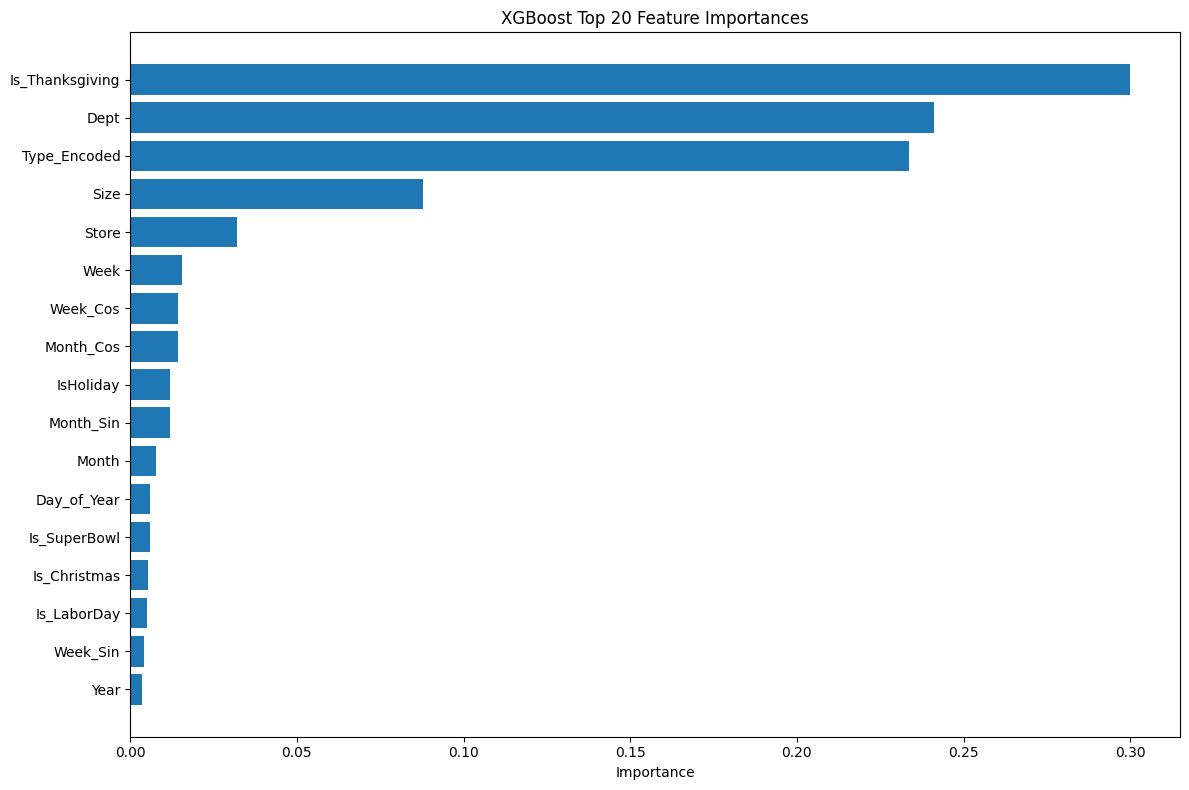


Top 10 features:
        feature  importance
Is_Thanksgiving    0.299945
           Dept    0.241197
   Type_Encoded    0.233681
           Size    0.087768
          Store    0.032180
           Week    0.015527
       Week_Cos    0.014205
      Month_Cos    0.014199
      IsHoliday    0.011940
      Month_Sin    0.011798


In [21]:
xgb_model = final_pipeline.named_steps['model']

importances = pd.DataFrame({
    'feature': BEST_FEATURES,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(importances['feature'].head(20)[::-1], importances['importance'].head(20)[::-1])
plt.title('XGBoost Top 20 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importances.head(10).to_string(index=False))

## 13. შეჯამება

XGBoost დასრულდა EDA-სა და 5 MLflow run-ით. Custom `WalmartPreprocessor` sklearn Transformer-ად აწყობილი Pipeline პირდაპირ raw CSV-ს იღებს და პროგნოზებს აბრუნებს — calendar/store ფიჩერების გარდა, Store×Dept lag/rolling ისტორიასა და Dept×Week სეზონურ საშუალოებსაც `fit`-ის დროს აგებს.

**Pipeline-ის ეტაპები:**
- დეტალური EDA — target-ის განაწილება, missing values, სეზონურობა, Store Type/Size/Dept ეფექტები
- Feature Selection ოთხ ვარიანტს შორის (`all`, `no_markdown`, `core`, `extended`) — `extended` (lag/rolling ისტორიით და Dept×Week სეზონურობით გამდიდრებული) მკვეთრად სჯობს სუფთა calendar/store ფიჩერებს
- 5-fold TimeSeriesSplit CV, სადაც თითოეული fold-ისთვის Preprocessor ცალკე fit-დება
- 9 curated კონფიგურაციის შედარება (`max_depth`/`learning_rate`/`regularization` balance)
- Holiday sample weight (`sample_weight`) გამოყენებულია ტრენინგის ყველა ეტაპზე — feature selection, CV, tuning, final — არა მხოლოდ საბოლოო შეფასებაში
- Hold-out ვალიდაცია + ცალკე production pipeline სრულ მონაცემზე

**შემდეგი:** N-BEATS, ARIMA/SARIMA, PatchTST notebook-ები. ბოლოს ყველა WMAE-ს ვადარებთ inference notebook-ში.